# Evaluation and Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
recommendation_df = pd.read_csv(
    "../data/recommendation_dataset.csv"
)

recommendation_df.shape

(1337, 20)

In [3]:
print(
    "Total Products:",
    recommendation_df['product_id'].nunique()
)

print(
    "Total Categories:",
    recommendation_df['category'].nunique()
)

print(
    "Average Rating:",
    round(
        recommendation_df['rating'].mean(),
        2
    )
)

print(
    "Average Popularity Score:",
    round(
        recommendation_df['popularity_score'].mean(),
        2
    )
)

Total Products: 1337
Total Categories: 211
Average Rating: 4.09
Average Popularity Score: 33.81


In [4]:
top_rated = (
    recommendation_df
    .sort_values(
        by='rating',
        ascending=False
    )
    .head(10)
    .copy()
)

In [5]:
top_rated['short_name'] = (
    top_rated['product_name']
    .str.slice(0,45)
    + "..."
)

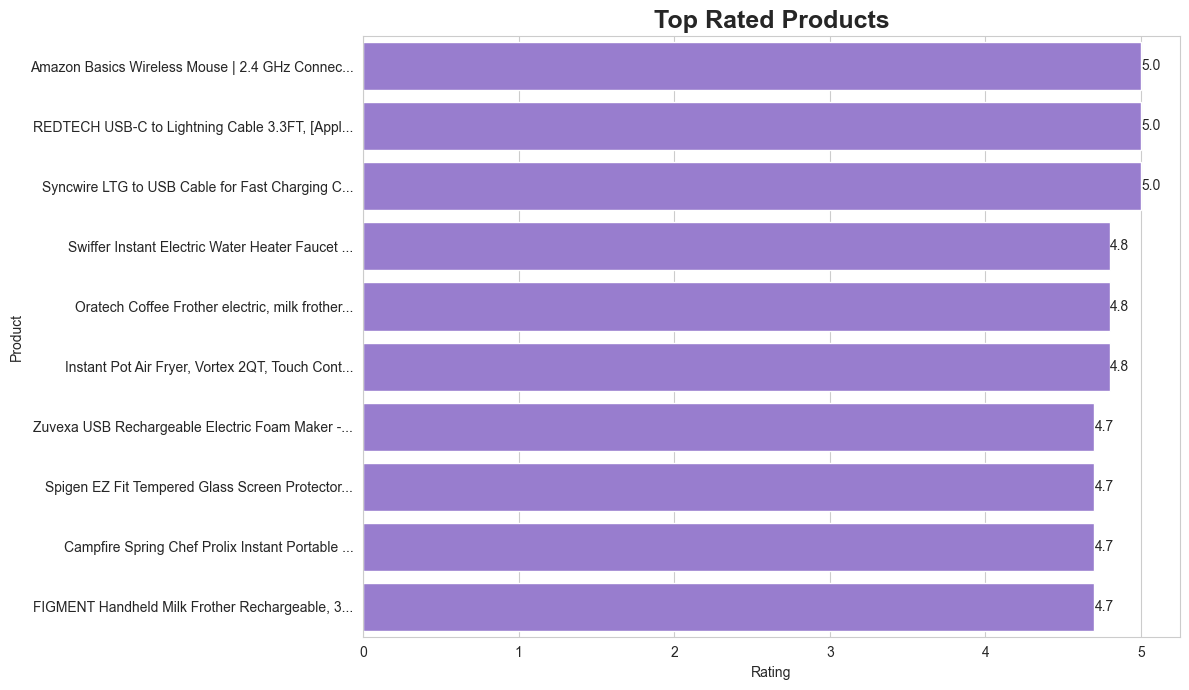

In [6]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_rated,
    x='rating',
    y='short_name',
    color='mediumpurple'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f'
    )

plt.title(
    "Top Rated Products",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Rating")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

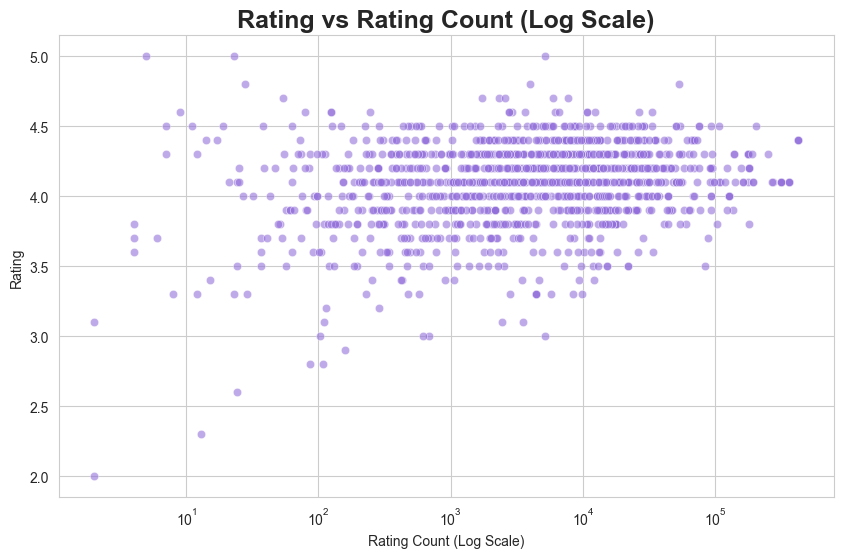

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=recommendation_df,
    x='rating_count',
    y='rating',
    color='mediumpurple',
    alpha=0.6
)

plt.xscale('log')

plt.title(
    "Rating vs Rating Count (Log Scale)",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Rating Count (Log Scale)")
plt.ylabel("Rating")

plt.show()

In [8]:
corr_matrix = recommendation_df[
    [
        'rating',
        'rating_count',
        'discount_percentage',
        'popularity_score'
    ]
].corr()

In [9]:
corr_matrix

,rating,rating_count,discount_percentage,popularity_score
rating,1.000000,0.096252,-0.168879,0.447721
rating_count,0.096252,1.000000,0.003513,0.547127
discount_percentage,-0.168879,0.003513,1.000000,-0.172672
popularity_score,0.447721,0.547127,-0.172672,1.000000


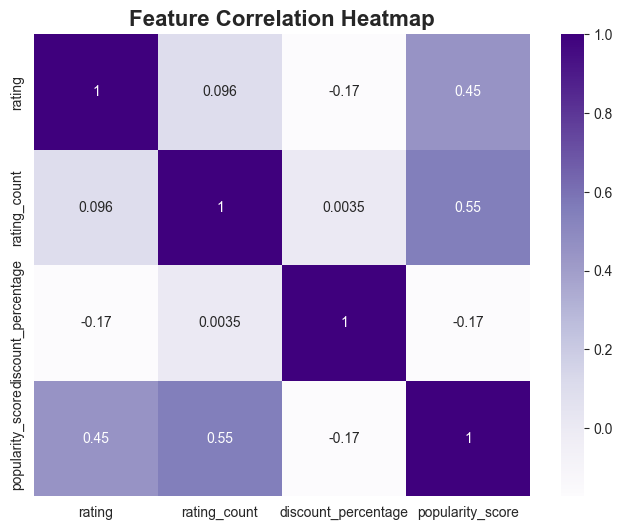

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Purples'
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [11]:
recommendation_df[
    'product_name'
].sample(3)

1333    Prestige Delight PRWO Electric Rice Cooker (1 ...
1305    Crompton Highspeed Markle Prime 1200 mm (48 in...
952     Room Heater Warmer Wall-Outlet 400 Watts Elect...
Name: product_name, dtype: str

# Recommendation Quality Evaluation

## Key Observations

- The Hybrid Recommendation System produced more balanced recommendations than the Content-Based Recommender alone.

- Products with similar descriptions and categories were frequently recommended together.

- Popularity weighting helped surface highly-rated products when multiple products had comparable similarity scores.

- The hybrid approach reduced the risk of recommending niche products with low engagement.

## Conclusion

Combining content similarity with popularity metrics improved the overall recommendation quality and produced more practical recommendations.

# Key Insights

## Dataset Insights

- Most products in the dataset maintain ratings above 4.0.
- Product popularity is strongly influenced by review volume.
- Review counts vary significantly across products, making logarithmic visualization more informative.

## Recommendation Insights

- Product descriptions and category information provide meaningful signals for content-based similarity.
- The Hybrid Recommendation System generated more robust recommendations than the content-based approach alone.
- Incorporating popularity scores improved recommendation relevance and ranking quality.

In [12]:
plt.savefig(
    "../reports/top_rated_products.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [13]:
plt.savefig(
    "../reports/correlation_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>